In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from google.colab import files

Saving image.jpeg to image (2).jpeg

IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 1
Enter transformation (1-4): 1
Enter tx: 10
Enter ty: 50


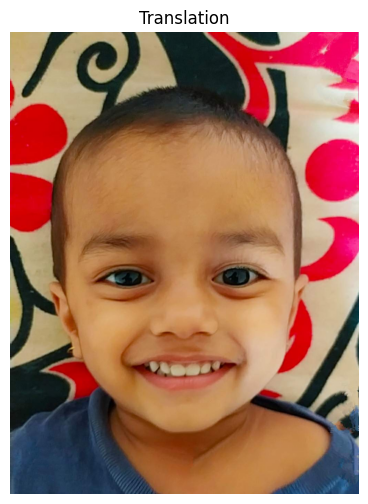


IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 1
Enter transformation (1-4): 2
Enter angle: 90


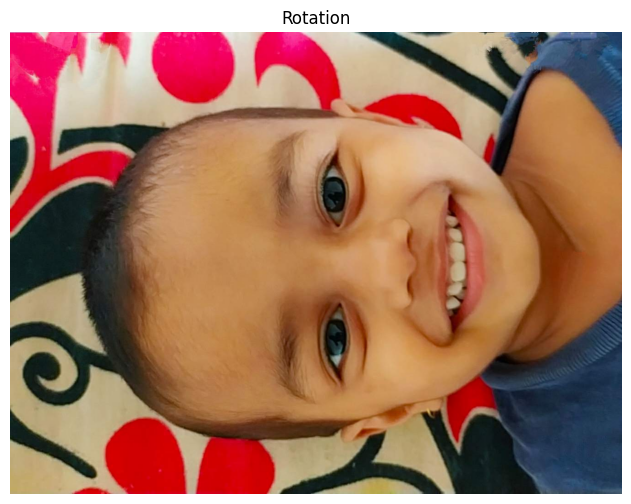


IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 1
Enter transformation (1-4): 3
Enter scale x: 10
Enter scale y: 20


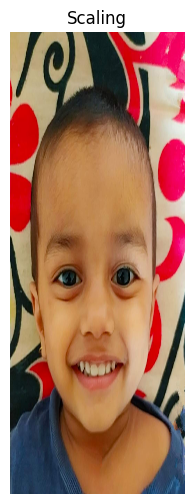


IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 1
Enter transformation (1-4): 4
Enter shear x: 10
Enter shear y: 40


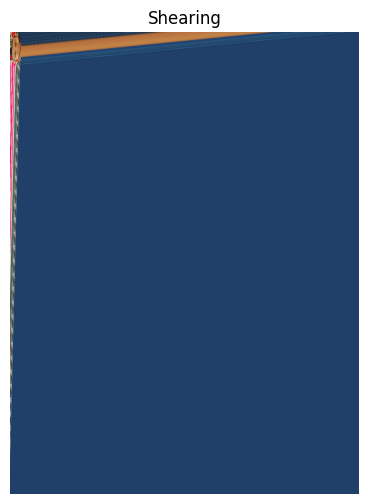


IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 2
Enter filter (1-4): 1


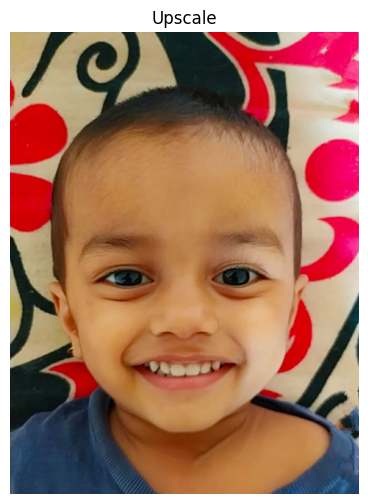


IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 2
Enter filter (1-4): 2


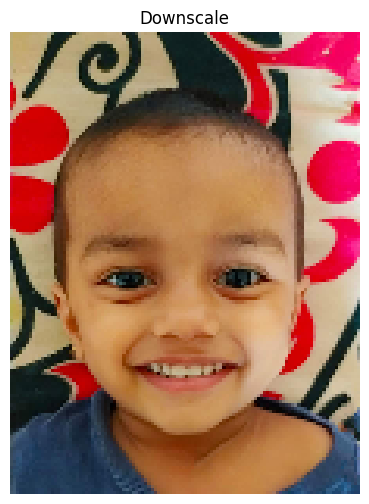


IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 2
Enter filter (1-4): 3
Enter kernel size: 5


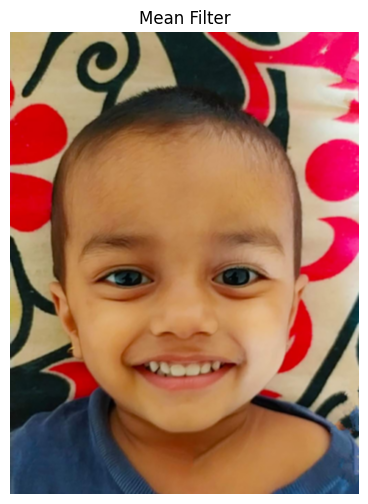


IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 2
Enter filter (1-4): 4
Enter kernel size: 5


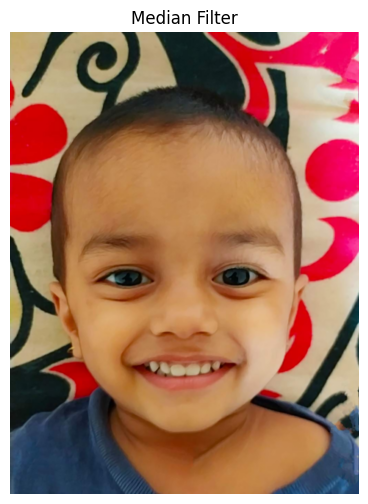


IMAGE TRANSFORMATION MENU
1. Geometric transformation
   1. Translation
   2. Rotation
   3. Scaling
   4. Shearing
2. Filters
   1. Upscale (Point Filter ×5)
   2. Downscale (Point Filter 1/9)
   3. Mean Filter
   4. Median Filter
0. Exit
Enter choice: 0


In [4]:


# ==========================================================
# IMAGE TRANSFORMER CLASS
# Handles geometric transformations and filters
# ==========================================================

class ImageTransformer:

    def __init__(self, image_path):

        self.image_path = image_path                             # Store the image path for later use

        self.img_pil = Image.open(image_path)                    # Load image using PIL
                                                                 # WHY: PIL is convenient for geometric operations like rotate and resize

        self.img_cv = cv2.imread(image_path)                     # Load image using OpenCV
                                                                 # WHY: Some filters and pixel operations are easier using OpenCV

        self.height, self.width = self.img_cv.shape[:2]          # Extract image dimensions
                                                                 # WHY: Needed when resizing or creating scaled images



    # ------------------ GEOMETRIC TRANSFORMATIONS ------------------

    def translate(self, tx=50, ty=30):                           # Translation shifts image position

        width, height = self.img_pil.size                        # Get original image size

                                                                 # Create a larger blank canvas
                                                                 # WHY: If we shift image, parts might go outside frame
                                                                 # so we create extra space to preserve pixels
        new_img = Image.new("RGB",
                            (int(width + abs(tx)*2), int(height + abs(ty)*2)),
                            (255,255,255))

                                                                 # Paste original image in center of new canvas
        new_img.paste(self.img_pil, (int(abs(tx)), int(abs(ty))))

                                                                 # Crop area according to translation values
        translated = new_img.crop((int(tx), int(ty), int(tx+width), int(ty+height)))

        return translated



    def rotate(self, angle=45):                                  # Rotate image by given angle

        rotated = self.img_pil.rotate(angle, expand=True)        # expand=True increases canvas
                                                                 # WHY: prevents image corners from being cropped

        return rotated



    def scale(self, sx=1.5, sy=0.8):                             # Resize image based on scale factors

        w, h = self.img_pil.size                                 # Original dimensions

        scaled = self.img_pil.resize((int(w*sx), int(h*sy)),
                                     Image.LANCZOS)
                                                                 # LANCZOS interpolation
                                                                 # WHY: provides high quality resizing

        return scaled



    def shear(self, shear_x=0.3, shear_y=0.2):                   # Shear transformation distorts image shape

        img_array = np.array(self.img_pil)                       # Convert PIL image to numpy array

        h, w = img_array.shape[:2]                               # Extract height and width

                                                                 # Generate coordinate grid
        X, Y = np.meshgrid(np.arange(w), np.arange(h))

                                                                 # Apply shear mapping
        shear_map_x = np.clip(X + shear_x * Y, 0, w-1).astype(np.int32)
        shear_map_y = np.clip(Y + shear_y * X, 0, h-1).astype(np.int32)

                                                                 # Map pixels to new positions
        sheared = img_array[shear_map_y, shear_map_x]

        return Image.fromarray(sheared)



    # ------------------ POINT FILTER SCALING ------------------

    def upscale_point_filter(self, factor=5):                    # Increase image size using nearest neighbor

        new_w = self.width * factor
        new_h = self.height * factor

        upscaled = cv2.resize(self.img_cv,
                              (new_w, new_h),
                              interpolation=cv2.INTER_NEAREST)
                                                                 # WHY: nearest neighbor replicates pixels
                                                                 # often used for point filtering

        return upscaled



    def downscale_point_filter(self, factor_denom=9):            # Reduce image size

        scale = 1 / factor_denom

        new_w = max(1, int(self.width * scale))
        new_h = max(1, int(self.height * scale))

        downscaled = cv2.resize(self.img_cv,
                                (new_w, new_h),
                                interpolation=cv2.INTER_NEAREST)

        return downscaled



    # ------------------ SPATIAL FILTERS ------------------

    def mean_filter(self, kernel_size=3):                        # Mean filter smooths image

                                                                 # Create averaging kernel
        kernel = np.ones((kernel_size, kernel_size),
                         np.float32) / (kernel_size*kernel_size)

        mean_filtered = cv2.filter2D(self.img_cv, -1, kernel)    # Convolution with kernel

        return mean_filtered



    def median_filter(self, kernel_size=3):                      # Median filter removes impulse noise

        median_filtered = cv2.medianBlur(self.img_cv,
                                         kernel_size)

        return median_filtered



    # ------------------ DISPLAY FUNCTIONS ------------------

    def display_pil(self, img, title):

        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")
        plt.show()



    def display_cv(self, img, title):

        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))         # Convert BGR to RGB
        plt.title(title)
        plt.axis("off")
        plt.show()



# ==========================================================
# FLEXIBLE AFFINE TRANSFORMATION CLASS
# Allows combining multiple transformations
# ==========================================================

class FlexibleAffine:

    def __init__(self, image_path):

        self.image_path = image_path
        self.img = None
        self.rows = None
        self.cols = None

        self.matrix = np.eye(3)                                  # Identity matrix
                                                                 # WHY: used as starting transformation



    def read_image(self):

        self.img = cv2.imread(self.image_path, 0)                 # Read grayscale image
        self.rows, self.cols = self.img.shape



    def add_rotation(self, angle):

        center = (self.cols // 2, self.rows // 2)

        rot = cv2.getRotationMatrix2D(center, angle, 1)

        rot = np.vstack([rot, [0,0,1]])                           # Convert to 3x3 matrix

        self.matrix = rot @ self.matrix                           # Combine transformation



    def add_scaling(self, sx, sy):

        scale = np.array([[sx,0,0],
                          [0,sy,0],
                          [0,0,1]])

        self.matrix = scale @ self.matrix



    def add_shearing(self, shx, shy):

        shear = np.array([[1,shx,0],
                          [shy,1,0],
                          [0,0,1]])

        self.matrix = shear @ self.matrix



    def add_translation(self, tx, ty):

        trans = np.array([[1,0,tx],
                          [0,1,ty],
                          [0,0,1]])

        self.matrix = trans @ self.matrix



    def apply(self):

        final_matrix = self.matrix[:2, :]                         # Convert 3x3 to 2x3

        result = cv2.warpAffine(self.img,
                                final_matrix,
                                (self.cols, self.rows))

        return result



    def display(self, result):

        plt.figure(figsize=(8,6))
        plt.imshow(result, cmap="gray")
        plt.axis("off")
        plt.show()



# ==========================================================
# MAIN MENU
# ==========================================================

def main_menu(transformer):

    while True:

        print("\nIMAGE TRANSFORMATION MENU")
        print("==================================================")
        print("1. Geometric transformation")
        print("   1. Translation")
        print("   2. Rotation")
        print("   3. Scaling")
        print("   4. Shearing")
        print("2. Filters")
        print("   1. Upscale (Point Filter ×5)")
        print("   2. Downscale (Point Filter 1/9)")
        print("   3. Mean Filter")
        print("   4. Median Filter")
        print("0. Exit")

        choice = input("Enter choice: ")

        if choice == "0":
            break


        elif choice == "1":

            sub = input("Enter transformation (1-4): ")

            if sub == "1":
                tx = float(input("Enter tx: "))
                ty = float(input("Enter ty: "))
                img = transformer.translate(tx, ty)
                transformer.display_pil(img,"Translation")

            elif sub == "2":
                angle = float(input("Enter angle: "))
                img = transformer.rotate(angle)
                transformer.display_pil(img,"Rotation")

            elif sub == "3":
                sx = float(input("Enter scale x: "))
                sy = float(input("Enter scale y: "))
                img = transformer.scale(sx, sy)
                transformer.display_pil(img,"Scaling")

            elif sub == "4":
                shx = float(input("Enter shear x: "))
                shy = float(input("Enter shear y: "))
                img = transformer.shear(shx, shy)
                transformer.display_pil(img,"Shearing")


        elif choice == "2":

            sub = input("Enter filter (1-4): ")

            if sub == "1":
                img = transformer.upscale_point_filter()
                transformer.display_cv(img,"Upscale")

            elif sub == "2":
                img = transformer.downscale_point_filter()
                transformer.display_cv(img,"Downscale")

            elif sub == "3":
                k = int(input("Enter kernel size: "))
                img = transformer.mean_filter(k)
                transformer.display_cv(img,"Mean Filter")

            elif sub == "4":
                k = int(input("Enter kernel size: "))
                img = transformer.median_filter(k)
                transformer.display_cv(img,"Median Filter")



# ==========================================================
# IMAGE UPLOAD AND EXECUTION
# ==========================================================

uploaded = files.upload()

for filename in uploaded.keys():

    path = os.path.abspath(filename)

    transformer = ImageTransformer(path)

    main_menu(transformer)